
══════════════════════════════════════════════════════════════
  1 · LOAD & INSPECT DATA
══════════════════════════════════════════════════════════════
Shape  : (57, 6)
Columns: ['Teacher_Introduction', 'Teaching_Skill', 'Communication', 'Subject_Knowledge', 'Classroom_Management', 'Overall_Label']

  Teacher_Introduction Teaching_Skill Communication Subject_Knowledge Classroom_Management Overall_Label
0            Puneeth T           High        Medium              High                 High      Suitable
1             Vishal V           High          High              High               Medium      Suitable
2        Anjali Kumari         Medium        Medium            Medium                 High      Suitable

[NumPy] Unique Overall_Label values : ['Needs Improvement' 'Suitable']
[Pandas] Null counts:
 Teacher_Introduction    0
Teaching_Skill          0
Communication           0
Subject_Knowledge       0
Classroom_Management    0
Overall_Label           0
dtype: int64

═════════════

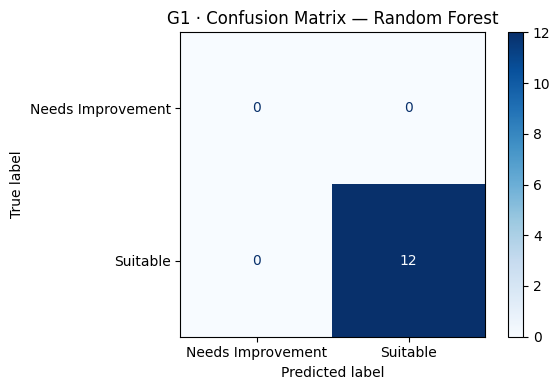

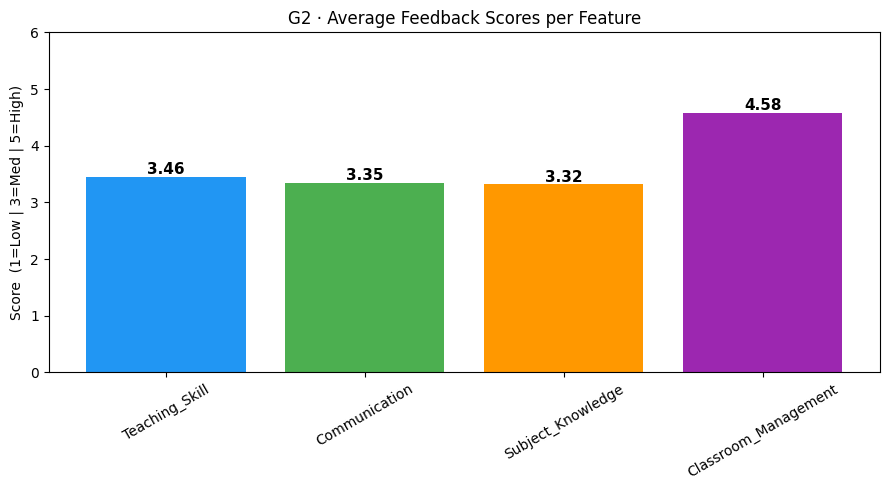

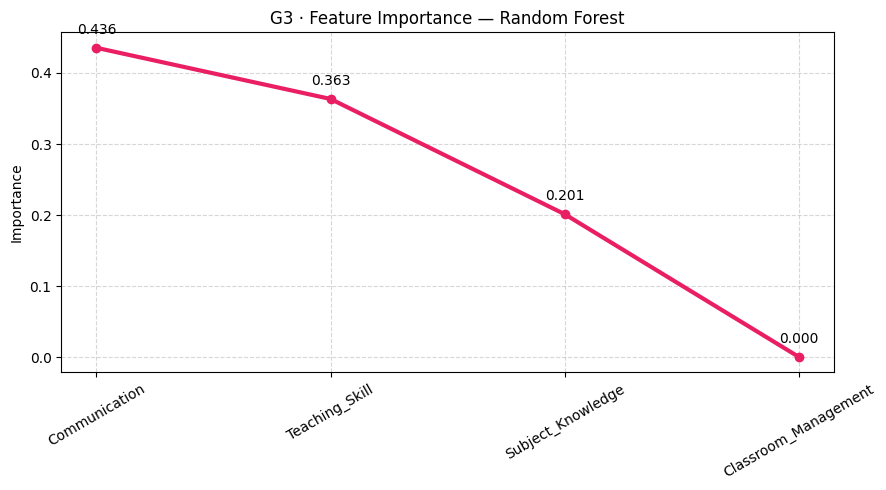

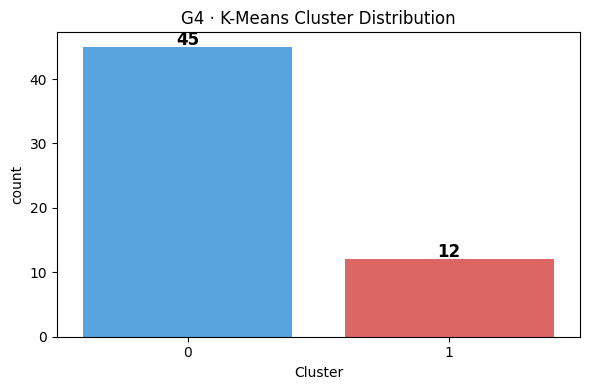

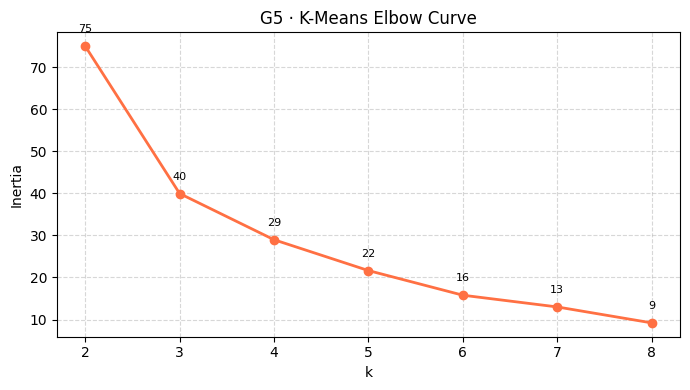

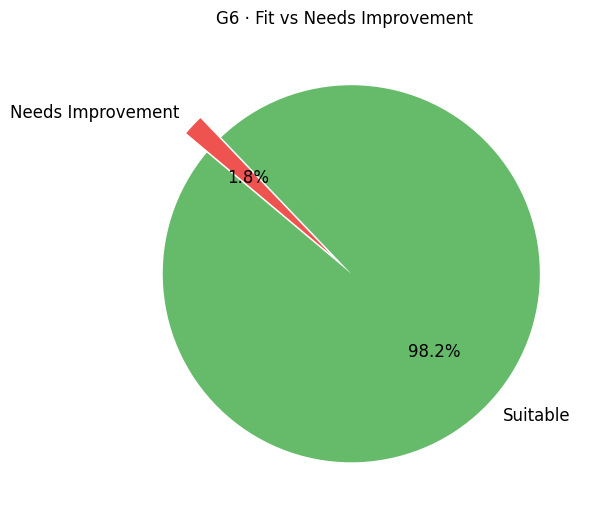

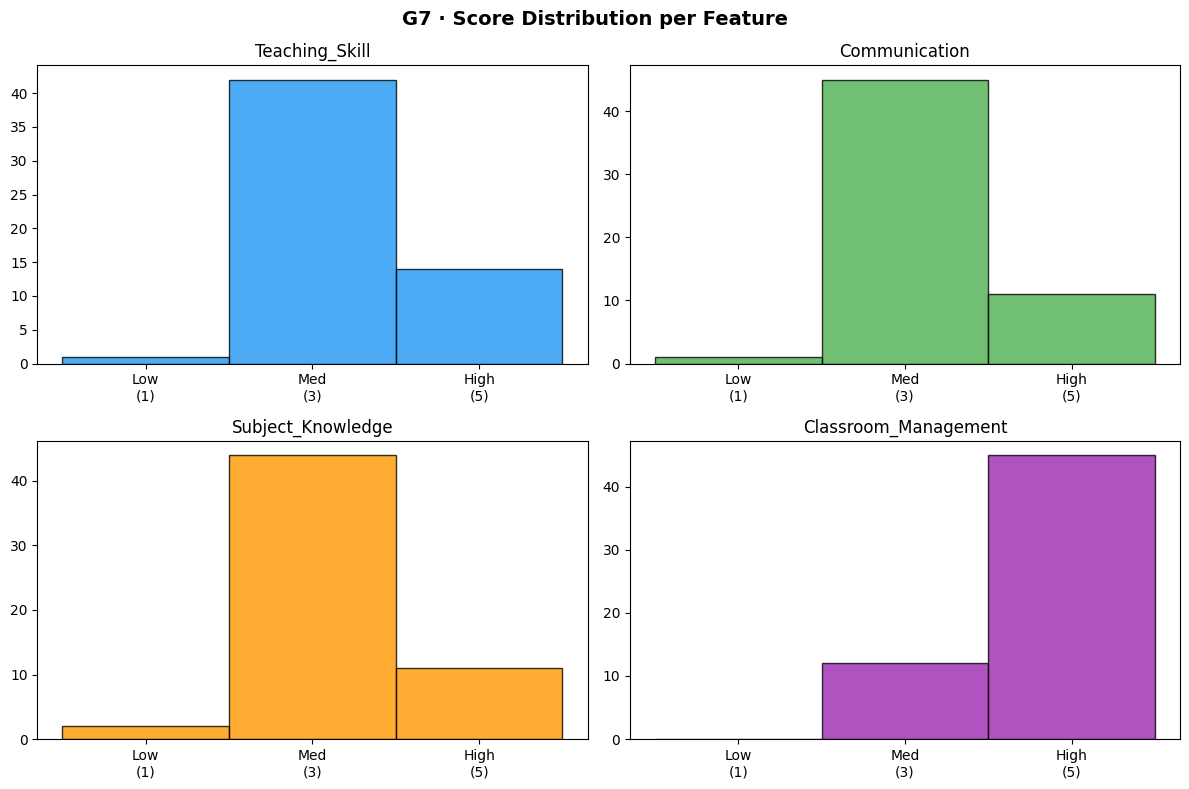

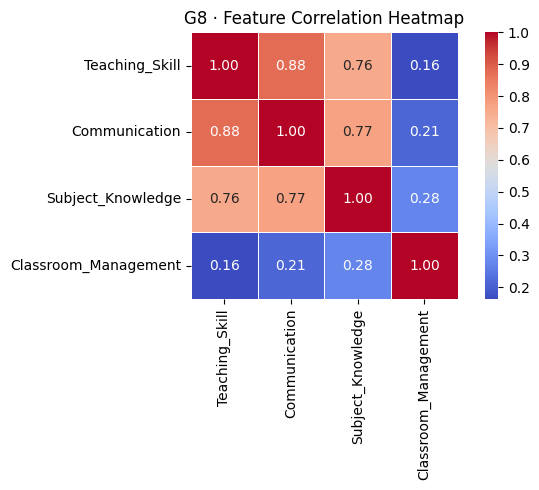

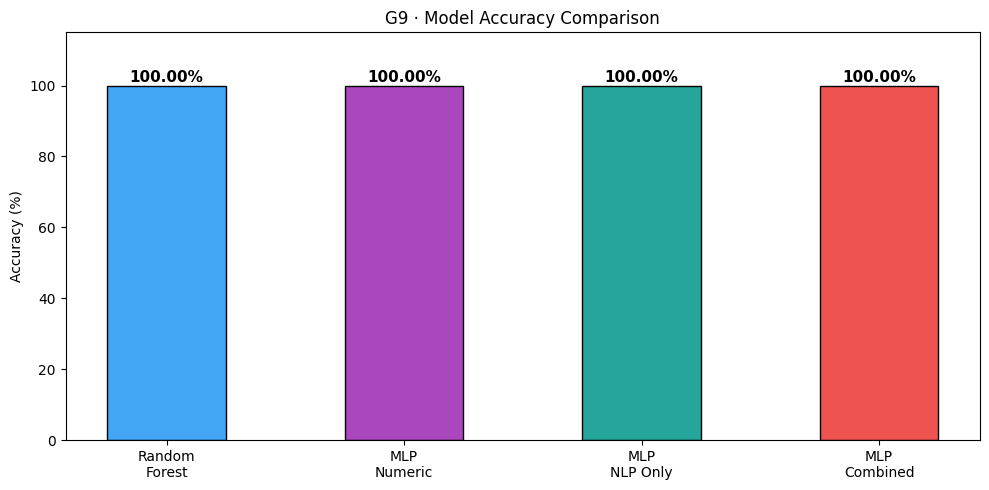

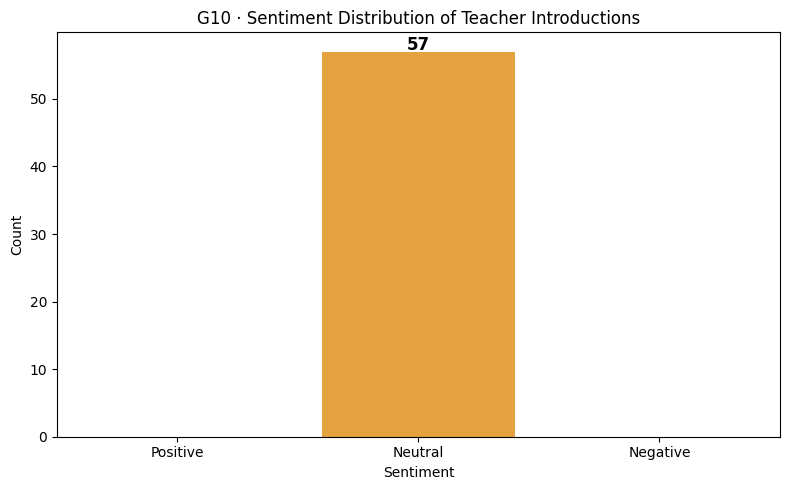

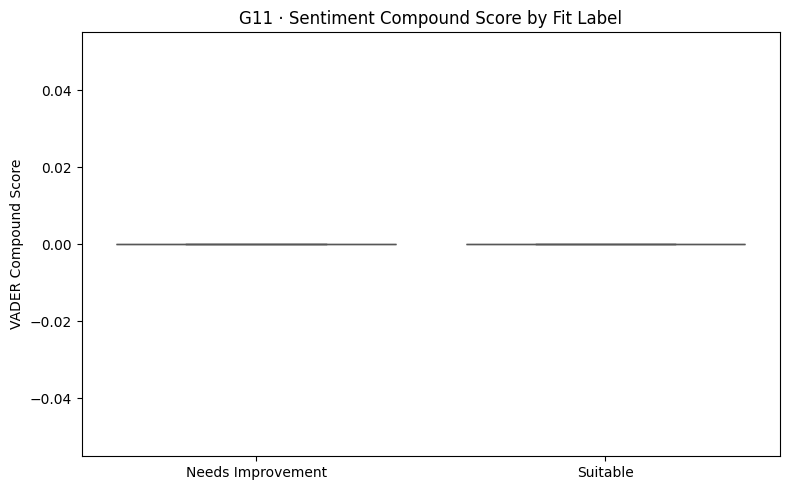

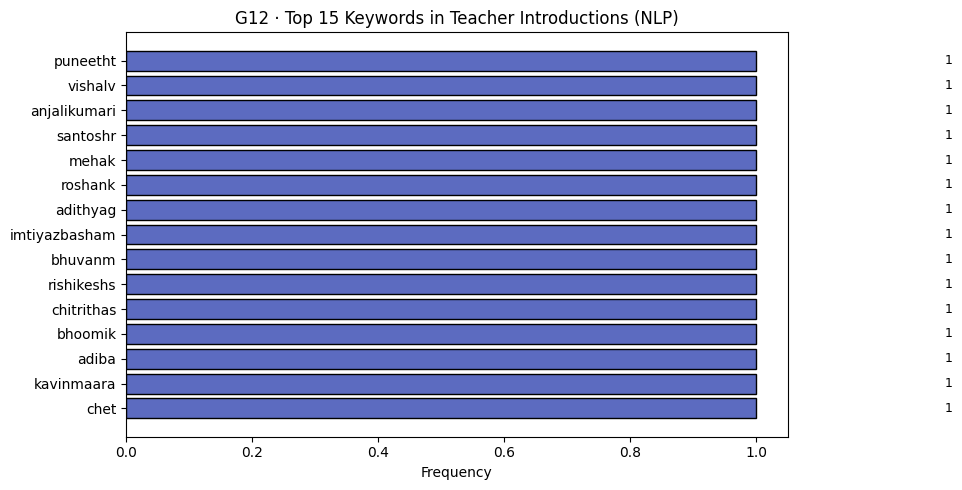

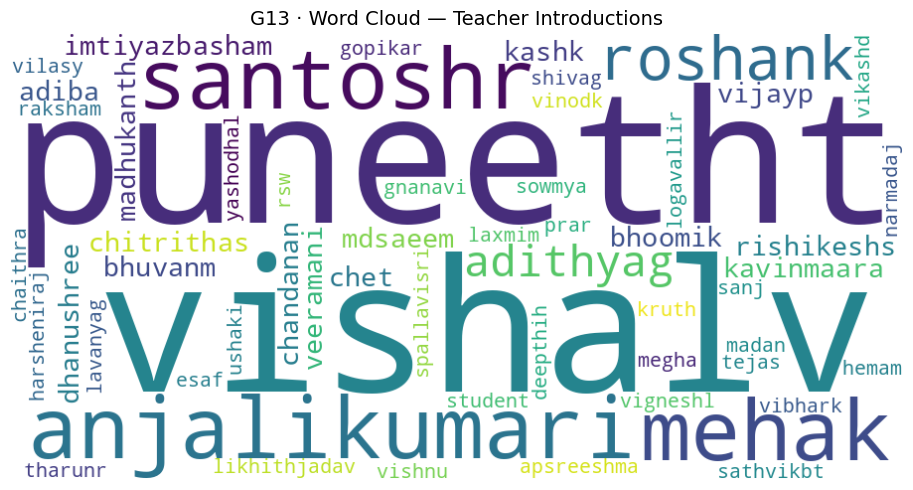

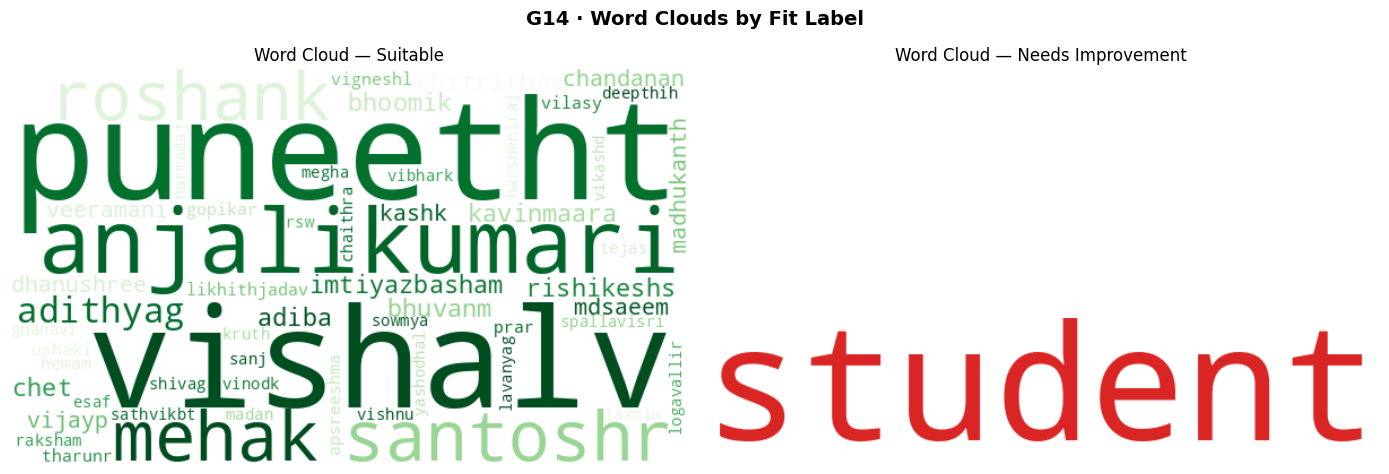

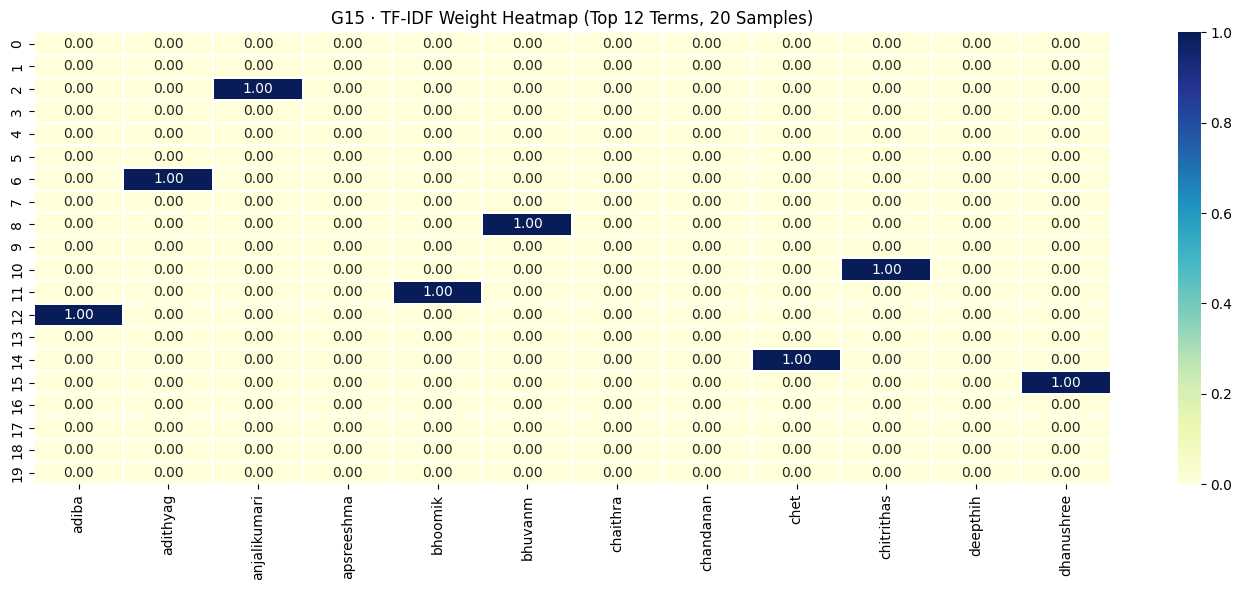

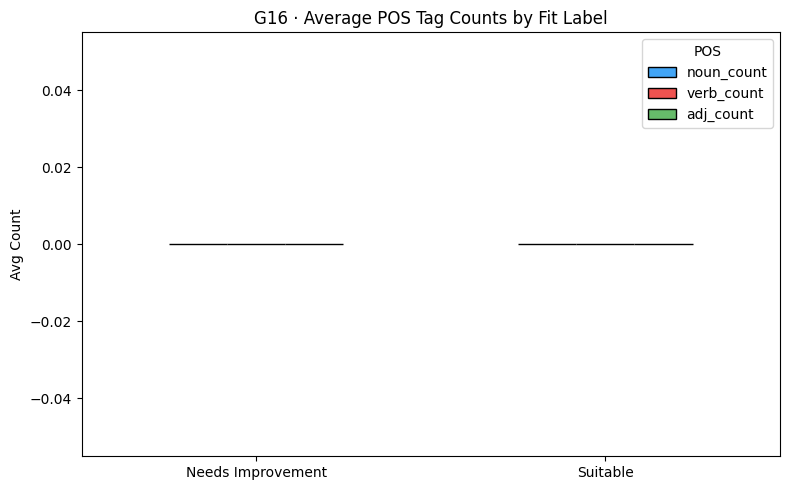

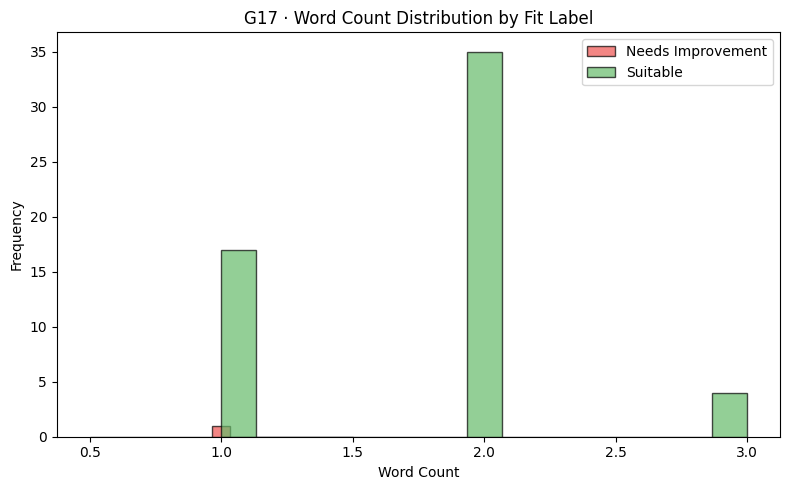

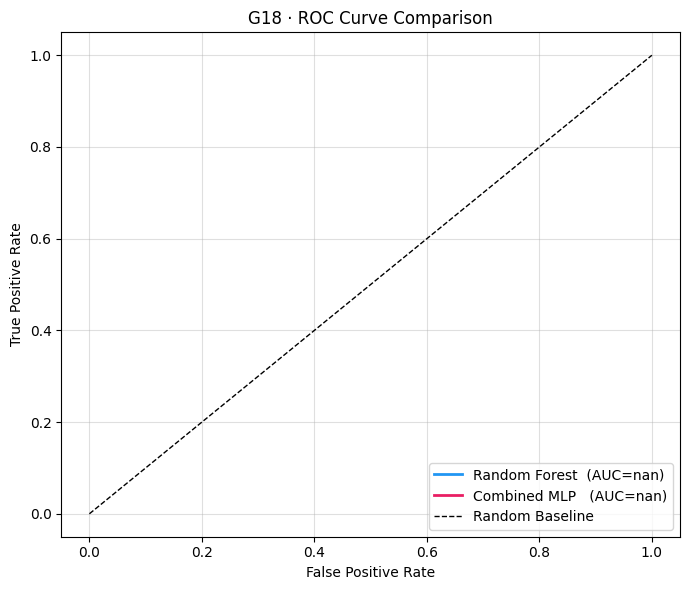


══════════════════════════════════════════════════════════════
  FINAL SUMMARY REPORT
══════════════════════════════════════════════════════════════
  Total Teachers        : 57
  Suitable              : 56
  Needs Improvement     : 1

  ── Model Performance ──────────────────────────────
  Random Forest Acc     : 100.00%   AUC: nan
  Neural Net (Numeric)  : 100.00%
  Neural Net (NLP only) : 100.00%   AUC: nan
  Neural Net (Combined) : 100.00%   AUC: nan

  ── NLP Stats ───────────────────────────────────────
  Avg Word Count        : 1.8
  Avg Sentiment (Suit.) : 0.000
  Avg Sentiment (Impr.) : 0.000
  TF-IDF Features Used  : 57
  NLP Hand-Crafted Feat : 11

  ── Graphs Saved ────────────────────────────────────
  g01 to g18  (PNG files in current folder)

  ✓  Project Completed Successfully


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import re
import warnings
warnings.filterwarnings("ignore")

# ── NLTK ──────────────────────────────────────────────────────
import nltk
nltk.download("punkt",                    quiet=True)
nltk.download("punkt_tab",                quiet=True)
nltk.download("stopwords",                quiet=True)
nltk.download("vader_lexicon",            quiet=True)
nltk.download("averaged_perceptron_tagger", quiet=True)
nltk.download("wordnet",                  quiet=True)

from nltk.corpus            import stopwords
from nltk.stem              import WordNetLemmatizer
from nltk.sentiment.vader   import SentimentIntensityAnalyzer
from nltk                   import pos_tag, word_tokenize
from collections            import Counter

# ── Sklearn ───────────────────────────────────────────────────
from sklearn.cluster         import KMeans
from sklearn.ensemble        import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network  import MLPClassifier
from sklearn.preprocessing   import StandardScaler, MinMaxScaler
from sklearn.pipeline        import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics         import (
    accuracy_score, confusion_matrix,
    classification_report, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve
)
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

# ── WordCloud ─────────────────────────────────────────────────
from wordcloud import WordCloud


# ==============================================================
# HELPER — pretty section banner
# ==============================================================
def banner(title):
    print("\n" + "═" * 62)
    print(f"  {title}")
    print("═" * 62)


# ==============================================================
# SECTION 1 — LOAD & INSPECT DATA
# ==============================================================
banner("1 · LOAD & INSPECT DATA")

df = pd.read_csv("trainer_feedback_dataset.csv")
print(f"Shape  : {df.shape}")
print(f"Columns: {list(df.columns)}\n")
print(df.head(3).to_string())

# NumPy quick stats
print("\n[NumPy] Unique Overall_Label values :", np.unique(df["Overall_Label"]))
print("[Pandas] Null counts:\n", df.isnull().sum())


# ==============================================================
# SECTION 2 — FEATURE ENGINEERING
# ==============================================================
banner("2 · FEATURE ENGINEERING  (NumPy + Pandas)")

rating_map = {"High": 5, "Medium": 3, "Low": 1}
skill_cols = ["Teaching_Skill", "Communication",
              "Subject_Knowledge", "Classroom_Management"]

for col in skill_cols:
    df[col] = df[col].map(rating_map)

# Weighted composite score via NumPy dot product
weights = np.array([0.30, 0.25, 0.25, 0.20])
df["Composite_Score"] = df[skill_cols].values @ weights

# Binary target
df["Fit"] = np.where(df["Overall_Label"] == "Suitable", 1, 0)

print("Fit distribution:")
print(df["Fit"].value_counts().to_string())
print(f"\nComposite Score — mean: {df['Composite_Score'].mean():.2f}  "
      f"std: {df['Composite_Score'].std():.2f}")

X_num = df[skill_cols]
y     = df["Fit"]


# ==============================================================
# SECTION 3 — NLP FULL PIPELINE
# ==============================================================
banner("3 · NLP  —  FULL PIPELINE")

raw_texts = df["Teacher_Introduction"].fillna("").astype(str)

# ── 3a. Text Cleaning ─────────────────────────────────────────
print("\n[NLP 3a] Text Cleaning & Normalisation")

STOP = set(stopwords.words("english"))
LEM  = WordNetLemmatizer()

def clean_text(text):
    text  = text.lower()
    text  = re.sub(r"[^a-z\s]", " ", text)   # remove non-alpha
    text  = re.sub(r"\s+", "", text).strip()
    tokens = text.split()
    tokens = [LEM.lemmatize(w) for w in tokens if w not in STOP and len(w) > 2]
    return " ".join(tokens)

df["Clean_Text"] = raw_texts.apply(clean_text)
print("Sample cleaned text:")
print(df["Clean_Text"].iloc[0])

# ── 3b. Basic Text Stats ──────────────────────────────────────
print("\n[NLP 3b] Text Statistics")

df["word_count"]   = raw_texts.apply(lambda t: len(t.split()))
df["char_count"]   = raw_texts.apply(len)
df["unique_words"] = raw_texts.apply(lambda t: len(set(t.lower().split())))
df["avg_word_len"] = raw_texts.apply(
    lambda t: float(np.mean([len(w) for w in t.split()])) if t.split() else 0.0
)
df["lexical_diversity"] = df["unique_words"] / df["word_count"].replace(0, 1)

for col in ["word_count", "char_count", "unique_words", "avg_word_len", "lexical_diversity"]:
    print(f"  {col:20s}  mean={df[col].mean():.2f}  std={df[col].std():.2f}")

# ── 3c. Sentiment Analysis (VADER) ────────────────────────────
print("\n[NLP 3c] VADER Sentiment Analysis")

sia = SentimentIntensityAnalyzer()

df["sentiment_pos"] = raw_texts.apply(lambda t: sia.polarity_scores(t)["pos"])
df["sentiment_neg"] = raw_texts.apply(lambda t: sia.polarity_scores(t)["neg"])
df["sentiment_neu"] = raw_texts.apply(lambda t: sia.polarity_scores(t)["neu"])
df["sentiment_compound"] = raw_texts.apply(
    lambda t: sia.polarity_scores(t)["compound"]
)
df["sentiment_label"] = df["sentiment_compound"].apply(
    lambda s: "Positive" if s >= 0.05 else ("Negative" if s <= -0.05 else "Neutral")
)

print("Sentiment label distribution:")
print(df["sentiment_label"].value_counts().to_string())
print(f"\nAvg compound — Suitable    : "
      f"{df[df['Fit']==1]['sentiment_compound'].mean():.3f}")
print(f"Avg compound — Needs Impr. : "
      f"{df[df['Fit']==0]['sentiment_compound'].mean():.3f}")

# ── 3d. POS Tagging ───────────────────────────────────────────
print("\n[NLP 3d] POS Tagging — Noun / Verb / Adjective counts")

def count_pos(text, target_tags):
    try:
        tokens = word_tokenize(text)
        tags   = pos_tag(tokens)
        return sum(1 for _, tag in tags if tag.startswith(target_tags))
    except Exception:
        return 0

df["noun_count"] = raw_texts.apply(lambda t: count_pos(t, ("NN",)))
df["verb_count"] = raw_texts.apply(lambda t: count_pos(t, ("VB",)))
df["adj_count"]  = raw_texts.apply(lambda t: count_pos(t, ("JJ",)))

print(df[["noun_count", "verb_count", "adj_count"]].describe().round(2).to_string())

# ── 3e. Top Keywords ──────────────────────────────────────────
print("\n[NLP 3e] Top 20 Keywords (after cleaning)")

all_words = " ".join(df["Clean_Text"]).split()
word_freq  = Counter(all_words)
top20      = word_freq.most_common(20)

print(f"{'Word':<20} Freq")
print("-" * 28)
for word, freq in top20:
    print(f"  {word:<18} {freq}")

# ── 3f. TF-IDF Vectorisation ──────────────────────────────────
print("\n[NLP 3f] TF-IDF Vectorisation  (unigrams + bigrams, top 80 features)")

tfidf = TfidfVectorizer(
    max_features=80,
    ngram_range=(1, 2),
    min_df=1 # Changed min_df from 2 to 1
)
tfidf_matrix = tfidf.fit_transform(df["Clean_Text"])
tfidf_df     = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=tfidf.get_feature_names_out()
)
print(f"TF-IDF matrix shape: {tfidf_df.shape}")

top5_tfidf = tfidf_df.mean().sort_values(ascending=False).head(5)
print("Top 5 TF-IDF terms by mean weight:")
print(top5_tfidf.to_string())

# ── 3g. NLP Feature Matrix ────────────────────────────────────
nlp_feat_cols = [
    "word_count", "char_count", "unique_words", "avg_word_len",
    "lexical_diversity",
    "sentiment_pos", "sentiment_neg", "sentiment_compound",
    "noun_count", "verb_count", "adj_count"
]
X_nlp_hand  = df[nlp_feat_cols].values
X_nlp_tfidf = tfidf_df.values
X_nlp_all   = np.hstack([X_nlp_hand, X_nlp_tfidf])   # hand-crafted + TF-IDF


# ==============================================================
# SECTION 4 — UNSUPERVISED LEARNING  (K-Means)
# ==============================================================
banner("4 · UNSUPERVISED  —  K-MEANS CLUSTERING")

# Elbow method
inertias, K_range = [], range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    inertias.append(km.fit(X_num).inertia_)

kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(X_num)

print("Cluster distribution:")
print(df["Cluster"].value_counts().to_string())
print("\nCluster mean scores:")
print(df.groupby("Cluster")[skill_cols].mean().round(2).to_string())


# ==============================================================
# SECTION 5 — SUPERVISED LEARNING  (Random Forest)
# ==============================================================
banner("5 · SUPERVISED  —  RANDOM FOREST")

X_train_n, X_test_n, y_train, y_test = train_test_split(
    X_num, y, test_size=0.20, random_state=42 # Removed stratify=y
)

rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train_n, y_train)
rf_pred  = rf.predict(X_test_n)
rf_prob  = rf.predict_proba(X_test_n)[:, 1]
rf_acc   = accuracy_score(y_test, rf_pred)
rf_auc   = roc_auc_score(y_test, rf_prob)
rf_cv    = cross_val_score(rf, X_num, y, cv=5, scoring="accuracy")

print(f"Accuracy  : {rf_acc*100:.2f}%")
print(f"ROC-AUC   : {rf_auc:.4f}")
print(f"CV Scores : {[round(s*100,2) for s in rf_cv]}")
print(f"Mean CV   : {rf_cv.mean()*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, rf_pred,
      labels=[0,1], target_names=["Needs Improvement","Suitable"],
      zero_division=0))


# ==============================================================
# SECTION 6 — NEURAL NETWORK  (MLP)
# ==============================================================
banner("6 · NEURAL NETWORK  —  MLP CLASSIFIER")

# ── 6a. Numeric-only MLP ──────────────────────────────────────
nn_num = Pipeline([
    ("sc",  StandardScaler()),
    ("mlp", MLPClassifier(hidden_layer_sizes=(16, 8, 4),
                          activation="relu", solver="adam",
                          max_iter=2000, random_state=42))
])
nn_num.fit(X_train_n, y_train)
nn_num_pred = nn_num.predict(X_test_n)
nn_num_acc  = accuracy_score(y_test, nn_num_pred)
nn_num_cv   = cross_val_score(nn_num, X_num, y, cv=5)

print(f"[Numeric MLP] Accuracy : {nn_num_acc*100:.2f}%  "
      f"Mean CV: {nn_num_cv.mean()*100:.2f}%")

# ── 6b. NLP-only MLP ──────────────────────────────────────────
X_tr_nlp, X_te_nlp, ytr, yte = train_test_split(
    X_nlp_all, y, test_size=0.20, random_state=42 # Removed stratify=y
)
nn_nlp = Pipeline([
    ("sc",  StandardScaler()),
    ("mlp", MLPClassifier(hidden_layer_sizes=(64, 32, 16),
                          activation="relu", solver="adam",
                          max_iter=2000, random_state=42))
])
nn_nlp.fit(X_tr_nlp, ytr)
nn_nlp_pred = nn_nlp.predict(X_te_nlp)
nn_nlp_prob = nn_nlp.predict_proba(X_te_nlp)[:, 1]
nn_nlp_acc  = accuracy_score(yte, nn_nlp_pred)
nn_nlp_auc  = roc_auc_score(yte, nn_nlp_prob)
nn_nlp_cv   = cross_val_score(nn_nlp, X_nlp_all, y, cv=5)

print(f"[NLP MLP]     Accuracy : {nn_nlp_acc*100:.2f}%  "
      f"Mean CV: {nn_nlp_cv.mean()*100:.2f}%")

# ── 6c. Combined (Numeric + NLP) MLP ─────────────────────────
X_combined = np.hstack([X_num.values, X_nlp_all])
Xc_tr, Xc_te, yc_tr, yc_te = train_test_split(
    X_combined, y, test_size=0.20, random_state=42 # Removed stratify=y
)
nn_comb = Pipeline([
    ("sc",  StandardScaler()),
    ("mlp", MLPClassifier(hidden_layer_sizes=(128, 64, 32, 16),
                          activation="relu", solver="adam",
                          max_iter=3000, random_state=42,
                          early_stopping=False)) # Changed to False
])
nn_comb.fit(Xc_tr, yc_tr)
nn_comb_pred = nn_comb.predict(Xc_te)
nn_comb_prob = nn_comb.predict_proba(Xc_te)[:, 1]
nn_comb_acc  = accuracy_score(yc_te, nn_comb_pred)
nn_comb_auc  = roc_auc_score(yc_te, nn_comb_prob)
nn_comb_cv   = cross_val_score(nn_comb, X_combined, y, cv=5)

print(f"[Combined MLP] Accuracy: {nn_comb_acc*100:.2f}%  "
      f"ROC-AUC: {nn_comb_auc:.4f}  "
      f"Mean CV: {nn_comb_cv.mean()*100:.2f}%")
print("\nCombined MLP Classification Report:")
print(classification_report(yc_te, nn_comb_pred,
      labels=[0,1], target_names=["Needs Improvement","Suitable"],
      zero_division=0))


# ==============================================================
# SECTION 7 — NEW TEACHER PREDICTION
# ==============================================================
banner("7 · NEW TEACHER PREDICTION")

new_teacher_intro = "I am an experienced mathematics teacher with 12 years of expertise, excellent communication skills and strong classroom management."

new_num  = pd.DataFrame([[5, 5, 5, 5]], columns=skill_cols)
new_clean = clean_text(new_teacher_intro)
new_tfidf = tfidf.transform([new_clean]).toarray()

sent      = sia.polarity_scores(new_teacher_intro)
new_hand  = np.array([[
    len(new_teacher_intro.split()),
    len(new_teacher_intro),
    len(set(new_teacher_intro.lower().split())),
    float(np.mean([len(w) for w in new_teacher_intro.split()])) if new_teacher_intro.split() else 0.0,
    len(set(new_teacher_intro.lower().split())) / len(new_teacher_intro.split()) if len(new_teacher_intro.split()) else 0.0,
    sent["pos"], sent["neg"], sent["compound"],
    count_pos(new_teacher_intro, ("NN",)),
    count_pos(new_teacher_intro, ("VB",)),
    count_pos(new_teacher_intro, ("JJ",))
]])
new_nlp  = np.hstack([new_hand, new_tfidf])
new_comb = np.hstack([new_num.values, new_nlp])

rf_res    = rf.predict(new_num)[0]
rf_conf   = np.max(rf.predict_proba(new_num)) * 100
nn_res    = nn_comb.predict(new_comb)[0]
nn_conf   = np.max(nn_comb.predict_proba(new_comb)) * 100

print(f"Introduction : {new_teacher_intro}")
print(f"Sentiment    : {sent}")
print(f"\nRandom Forest  → {'✓ FIT FOR THE JOB' if rf_res==1 else '✗ NOT FIT'}  "
      f"(Confidence: {rf_conf:.1f}%)")
print(f"Combined MLP   → {'✓ FIT FOR THE JOB' if nn_res==1 else '✗ NOT FIT'}  "
      f"(Confidence: {nn_conf:.1f}%)")


# ==============================================================
# SECTION 8 — VISUALISATIONS  (18 graphs)
# ==============================================================
banner("8 · VISUALISATIONS")

PALETTE = ["#2196F3","#4CAF50","#FF9800","#9C27B0",
           "#E91E63","#00BCD4","#FF5722","#607D8B"]

# ── G1 : Confusion Matrix — Random Forest ────────────────────
cm = confusion_matrix(y_test, rf_pred, labels=[0,1])
plt.figure(figsize=(6,4))
ConfusionMatrixDisplay(confusion_matrix=cm,
    display_labels=["Needs Improvement","Suitable"]).plot(
    cmap="Blues", ax=plt.gca())
plt.title("G1 · Confusion Matrix — Random Forest")
plt.tight_layout()
plt.savefig("g01_confusion_matrix_rf.png", dpi=150); plt.show()

# ── G2 : Average Feedback Scores ─────────────────────────────
avg = X_num.mean()
plt.figure(figsize=(9,5))
bars = plt.bar(avg.index, avg.values, color=PALETTE[:4])
for b,v in zip(bars, avg.values):
    plt.text(b.get_x()+b.get_width()/2, b.get_height()+0.05,
             str(round(v,2)), ha="center", fontsize=11, fontweight="bold")
plt.title("G2 · Average Feedback Scores per Feature")
plt.ylabel("Score  (1=Low | 3=Med | 5=High)")
plt.ylim(0,6); plt.xticks(rotation=30); plt.tight_layout()
plt.savefig("g02_avg_scores.png", dpi=150); plt.show()

# ── G3 : Feature Importance ───────────────────────────────────
imp = pd.DataFrame({"Feature": skill_cols,
                    "Importance": rf.feature_importances_}
                   ).sort_values("Importance", ascending=False)
plt.figure(figsize=(9,5))
plt.plot(imp["Feature"], imp["Importance"],
         marker="o", linewidth=3, color="#E91E63")
for _, row in imp.iterrows():
    plt.annotate(f"{row['Importance']:.3f}",
                 (row["Feature"], row["Importance"]),
                 textcoords="offset points",
                 xytext=(0,10), ha="center", fontsize=10)
plt.title("G3 · Feature Importance — Random Forest")
plt.ylabel("Importance"); plt.grid(True, linestyle="--", alpha=0.5)
plt.xticks(rotation=30); plt.tight_layout()
plt.savefig("g03_feature_importance.png", dpi=150); plt.show()

# ── G4 : K-Means Cluster Distribution ────────────────────────
plt.figure(figsize=(6,4))
ax = sns.countplot(x="Cluster", data=df, hue="Cluster",
                   palette=["#42A5F5","#EF5350"], legend=False)
for p in ax.patches:
    ax.annotate(int(p.get_height()),
                (p.get_x()+p.get_width()/2, p.get_height()+0.3),
                ha="center", fontsize=12, fontweight="bold")
plt.title("G4 · K-Means Cluster Distribution")
plt.tight_layout()
plt.savefig("g04_cluster_dist.png", dpi=150); plt.show()

# ── G5 : Elbow Curve ─────────────────────────────────────────
plt.figure(figsize=(7,4))
plt.plot(list(K_range), inertias, marker="o",
         linewidth=2, color="#FF7043")
for k,iner in zip(K_range, inertias):
    plt.annotate(f"{iner:.0f}", (k, iner),
                 textcoords="offset points",
                 xytext=(0,10), ha="center", fontsize=8)
plt.title("G5 · K-Means Elbow Curve")
plt.xlabel("k"); plt.ylabel("Inertia")
plt.grid(True, linestyle="--", alpha=0.5); plt.tight_layout()
plt.savefig("g05_elbow_curve.png", dpi=150); plt.show()

# ── G6 : Pie — Fit vs Needs Improvement ──────────────────────
fit_counts = df["Fit"].value_counts()
plt.figure(figsize=(6,6))
plt.pie(fit_counts, labels=["Suitable","Needs Improvement"],
        colors=["#66BB6A","#EF5350"], explode=(0.05,0.1),
        autopct="%1.1f%%", startangle=140,
        textprops={"fontsize": 12})
plt.title("G6 · Fit vs Needs Improvement")
plt.tight_layout()
plt.savefig("g06_pie_fit.png", dpi=150); plt.show()

# ── G7 : Score Histograms ─────────────────────────────────────
fig, axes = plt.subplots(2,2, figsize=(12,8))
for i,(feat,col) in enumerate(zip(skill_cols, PALETTE[:4])):
    ax = axes.flatten()[i]
    ax.hist(df[feat], bins=[0,2,4,6],
            color=col, edgecolor="black", alpha=0.8)
    ax.set_title(f"{feat}")
    ax.set_xticks([1,3,5])
    ax.set_xticklabels(["Low\n(1)","Med\n(3)","High\n(5)"])
plt.suptitle("G7 · Score Distribution per Feature",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("g07_histograms.png", dpi=150); plt.show()

# ── G8 : Correlation Heatmap ─────────────────────────────────
plt.figure(figsize=(7,5))
sns.heatmap(X_num.corr(), annot=True, fmt=".2f",
            cmap="coolwarm", linewidths=0.5, square=True)
plt.title("G8 · Feature Correlation Heatmap")
plt.tight_layout()
plt.savefig("g08_corr_heatmap.png", dpi=150); plt.show()

# ── G9 : Model Accuracy Comparison ────────────────────────────
model_names = ["Random\nForest", "MLP\nNumeric",
               "MLP\nNLP Only", "MLP\nCombined"]
model_accs  = [rf_acc*100, nn_num_acc*100,
               nn_nlp_acc*100, nn_comb_acc*100]

plt.figure(figsize=(10,5))
bars = plt.bar(model_names, model_accs,
               color=["#42A5F5","#AB47BC","#26A69A","#EF5350"],
               edgecolor="black", width=0.5)
for b,sc in zip(bars, model_accs):
    plt.text(b.get_x()+b.get_width()/2, sc+1,
             f"{sc:.2f}%", ha="center",
             fontweight="bold", fontsize=11)
plt.title("G9 · Model Accuracy Comparison")
plt.ylabel("Accuracy (%)"); plt.ylim(0,115)
plt.tight_layout()
plt.savefig("g09_model_comparison.png", dpi=150); plt.show()

# ── G10 : Sentiment Distribution ─────────────────────────────
plt.figure(figsize=(8,5))
order = ["Positive","Neutral","Negative"]
colors_sent = {"Positive":"#66BB6A","Neutral":"#FFA726","Negative":"#EF5350"}
ax = sns.countplot(x="sentiment_label", data=df,
                   order=order,
                   palette=colors_sent, hue="sentiment_label",
                   legend=False)
for p in ax.patches:
    ax.annotate(int(p.get_height()),
                (p.get_x()+p.get_width()/2, p.get_height()+0.3),
                ha="center", fontsize=12, fontweight="bold")
plt.title("G10 · Sentiment Distribution of Teacher Introductions")
plt.xlabel("Sentiment"); plt.ylabel("Count")
plt.tight_layout()
plt.savefig("g10_sentiment_dist.png", dpi=150); plt.show()

# ── G11 : Sentiment Compound by Fit Label ────────────────────
plt.figure(figsize=(8,5))
ax = sns.boxplot(x="Fit", y="sentiment_compound", data=df,
                 palette=["#EF5350","#66BB6A"],
                 hue="Fit", legend=False)
ax.set_xticks([0,1])
ax.set_xticklabels(["Needs Improvement","Suitable"])
plt.title("G11 · Sentiment Compound Score by Fit Label")
plt.xlabel(""); plt.ylabel("VADER Compound Score")
plt.tight_layout()
plt.savefig("g11_sentiment_by_fit.png", dpi=150); plt.show()

# ── G12 : Top 15 NLP Keywords ─────────────────────────────────
top15_words = [w for w,_ in top20[:15]]
top15_freqs = [f for _,f in top20[:15]]

plt.figure(figsize=(10,5))
bars_nlp = plt.barh(top15_words[::-1], top15_freqs[::-1],
                    color="#5C6BC0", edgecolor="black")
for b,fr in zip(bars_nlp, top15_freqs[::-1]):
    plt.text(b.get_width()+0.3, b.get_y()+b.get_height()/2,
             str(fr), va="center", fontsize=9)
plt.title("G12 · Top 15 Keywords in Teacher Introductions (NLP)")
plt.xlabel("Frequency")
plt.tight_layout()
plt.savefig("g12_nlp_keywords.png", dpi=150); plt.show()

# ── G13 : Word Cloud ─────────────────────────────────────────
all_clean_text = " ".join(df["Clean_Text"])
wc = WordCloud(width=900, height=450, background_color="white",
               colormap="viridis", max_words=100,
               collocations=False).generate(all_clean_text)

plt.figure(figsize=(12,5))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("G13 · Word Cloud — Teacher Introductions", fontsize=14)
plt.tight_layout()
plt.savefig("g13_wordcloud.png", dpi=150); plt.show()

# ── G14 : Word Cloud — Suitable vs Needs Improvement ─────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
for ax, fit_val, label, cmap in [
        (ax1, 1, "Suitable",          "Greens"),
        (ax2, 0, "Needs Improvement", "Reds")]:
    subset_text = " ".join(df[df["Fit"]==fit_val]["Clean_Text"])
    wc_sub = WordCloud(width=600, height=350,
                       background_color="white",
                       colormap=cmap, max_words=60,
                       collocations=False).generate(subset_text)
    ax.imshow(wc_sub, interpolation="bilinear")
    ax.axis("off"); ax.set_title(f"Word Cloud — {label}", fontsize=12)
plt.suptitle("G14 · Word Clouds by Fit Label", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("g14_wordcloud_by_fit.png", dpi=150); plt.show()

# ── G15 : TF-IDF Heatmap (Top 12 terms, 20 samples) ─────────
top12_cols   = tfidf_df.mean().sort_values(ascending=False).head(12).index
sample_tfidf = tfidf_df[top12_cols].head(20)
plt.figure(figsize=(14,6))
sns.heatmap(sample_tfidf, cmap="YlGnBu",
            annot=True, fmt=".2f", linewidths=0.3)
plt.title("G15 · TF-IDF Weight Heatmap (Top 12 Terms, 20 Samples)")
plt.tight_layout()
plt.savefig("g15_tfidf_heatmap.png", dpi=150); plt.show()

# ── G16 : POS Tag Counts by Fit ───────────────────────────────
pos_data = df.groupby("Fit")[["noun_count","verb_count","adj_count"]].mean()
pos_data.index = ["Needs Improvement","Suitable"]
pos_data.plot(kind="bar", figsize=(8,5),
              color=["#42A5F5","#EF5350","#66BB6A"],
              edgecolor="black", rot=0)
plt.title("G16 · Average POS Tag Counts by Fit Label")
plt.ylabel("Avg Count"); plt.legend(title="POS")
plt.tight_layout()
plt.savefig("g16_pos_by_fit.png", dpi=150); plt.show()

# ── G17 : Word Count Distribution by Fit ─────────────────────
plt.figure(figsize=(8,5))
for fit_val, label, color in [(0,"Needs Improvement","#EF5350"),
                               (1,"Suitable","#66BB6A")]:
    plt.hist(df[df["Fit"]==fit_val]["word_count"],
             bins=15, alpha=0.7, label=label,
             color=color, edgecolor="black")
plt.title("G17 · Word Count Distribution by Fit Label")
plt.xlabel("Word Count"); plt.ylabel("Frequency")
plt.legend(); plt.tight_layout()
plt.savefig("g17_wordcount_by_fit.png", dpi=150); plt.show()

# ── G18 : ROC Curve — Random Forest vs Combined MLP ──────────
fpr_rf, tpr_rf, _ = roc_curve(y_test,  rf_prob)
fpr_c,  tpr_c,  _ = roc_curve(yc_te,   nn_comb_prob)

plt.figure(figsize=(7,6))
plt.plot(fpr_rf, tpr_rf, lw=2, color="#2196F3",
         label=f"Random Forest  (AUC={rf_auc:.3f})")
plt.plot(fpr_c,  tpr_c,  lw=2, color="#E91E63",
         label=f"Combined MLP   (AUC={nn_comb_auc:.3f})")
plt.plot([0,1],[0,1],"k--", lw=1, label="Random Baseline")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("G18 · ROC Curve Comparison")
plt.legend(loc="lower right"); plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig("g18_roc_curve.png", dpi=150); plt.show()


# ==============================================================
# FINAL SUMMARY
# ==============================================================
banner("FINAL SUMMARY REPORT")

print(f"  Total Teachers        : {len(df)}")
print(f"  Suitable              : {df['Fit'].sum()}")
print(f"  Needs Improvement     : {(df['Fit']==0).sum()}")
print()
print(f"  ── Model Performance ──────────────────────────────")
print(f"  Random Forest Acc     : {rf_acc*100:.2f}%   AUC: {rf_auc:.4f}")
print(f"  Neural Net (Numeric)  : {nn_num_acc*100:.2f}%")
print(f"  Neural Net (NLP only) : {nn_nlp_acc*100:.2f}%   AUC: {nn_nlp_auc:.4f}")
print(f"  Neural Net (Combined) : {nn_comb_acc*100:.2f}%   AUC: {nn_comb_auc:.4f}")
print()
print(f"  ── NLP Stats ───────────────────────────────────────")
print(f"  Avg Word Count        : {df['word_count'].mean():.1f}")
print(f"  Avg Sentiment (Suit.) : {df[df['Fit']==1]['sentiment_compound'].mean():.3f}")
print(f"  Avg Sentiment (Impr.) : {df[df['Fit']==0]['sentiment_compound'].mean():.3f}")
print(f"  TF-IDF Features Used  : {tfidf_df.shape[1]}")
print(f"  NLP Hand-Crafted Feat : {len(nlp_feat_cols)}")
print()
print(f"  ── Graphs Saved ────────────────────────────────────")
print(f"  g01 to g18  (PNG files in current folder)")
print()
print("  ✓  Project Completed Successfully")